## 1. Mount Google Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Load the CSV from Google Drive
file_path = '/content/drive/MyDrive/data/Tesla.csv'
df = pd.read_csv(file_path)

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (1692, 7)

First 5 rows:


,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


## 2. Data Preparation

In [ ]:
# Keep only Date and Open columns
df = df[['Date', 'Open']].copy()

# Parse dates and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print('Date range:', df['Date'].min(), '→', df['Date'].max())
print('Total trading days:', len(df))
print('\nMissing values:', df.isnull().sum().sum())
print('\nOpen price statistics:')
df['Open'].describe()

Date range: 2010-06-29 00:00:00 → 2017-03-17 00:00:00
Total trading days: 1692

Missing values: 0

Open price statistics:


,Open
count,1692.000000
mean,132.441572
std,94.309923
min,16.139999
25%,30.000000
50%,156.334999
75%,220.557495
max,287.670013


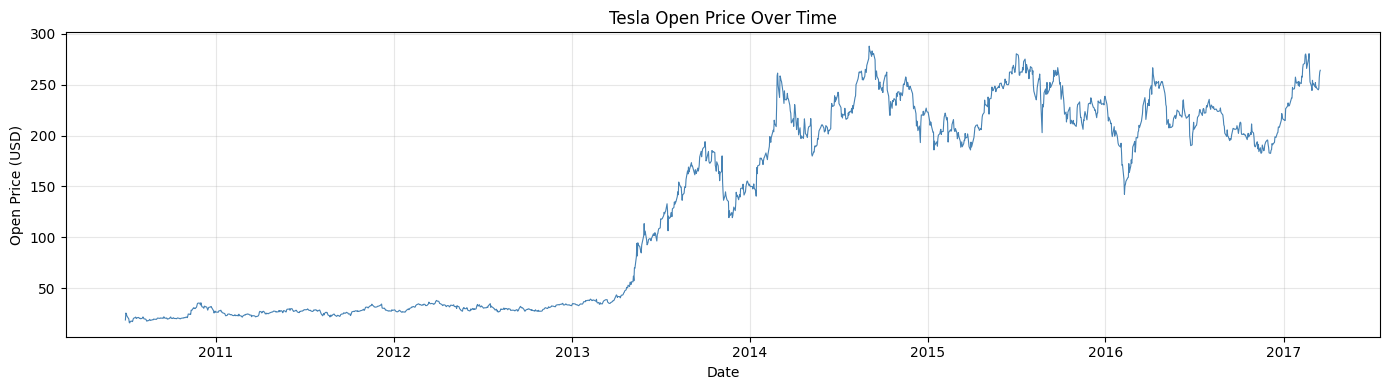

In [ ]:
# Visualize the raw Open price
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['Open'], color='steelblue', linewidth=0.8)
plt.title('Tesla Open Price Over Time')
plt.xlabel('Date')
plt.ylabel('Open Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Scaling

In [ ]:
# Train/Test split (80/20) — split before scaling
WINDOW_SIZE = 30   # use 30 days to predict day 31
TRAIN_RATIO = 0.8

values = df['Open'].values.reshape(-1, 1)

split_idx = int(len(values) * TRAIN_RATIO)
train_raw = values[:split_idx]
test_raw  = values[split_idx:]

print(f'Train samples: {len(train_raw)} | Test samples: {len(test_raw)}')

# Fit scaler on train only
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)

# Transform test using the same scaler (no re-fitting)
# We include the last WINDOW_SIZE points of train so we can
# form the very first test window without a gap.
test_scaled = scaler.transform(test_raw)

Train samples: 1353 | Test samples: 339


## 4. Sliding Window — Build X and y
Each sample: `X[i]` = days `[i … i+29]`, `y[i]` = day `i+30`

In [ ]:
def create_sequences(data, window_size):
    """
    Slide a window of `window_size` over `data`.
    Returns:
        X : shape (n_samples, window_size, 1)
        y : shape (n_samples,)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])       # 30-day window
        y.append(data[i + window_size])            # day 31
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_scaled,  WINDOW_SIZE)

print(f'X_train shape: {X_train.shape}  →  (samples, timesteps, features)')
print(f'y_train shape: {y_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'y_test  shape: {y_test.shape}')

X_train shape: (1323, 30, 1)  →  (samples, timesteps, features)
y_train shape: (1323, 1)
X_test  shape: (309, 30, 1)
y_test  shape: (309, 1)


## 5. Build the LSTM Model

In [ ]:
def build_lstm(window_size, units=64, dropout=0.2):
    model = Sequential([
        # First LSTM layer — return sequences so the next LSTM can see them
        LSTM(units, return_sequences=True, input_shape=(window_size, 1)),
        Dropout(dropout),

        # Second LSTM layer
        LSTM(units // 2, return_sequences=False),
        Dropout(dropout),

        # Output: a single value (day-31 Open price, normalized)
        Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )
    return model

model = build_lstm(WINDOW_SIZE)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,     # 10% of train data used for validation
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 0.0304 - val_loss: 0.0024
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0042 - val_loss: 0.0026
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0041 - val_loss: 0.0037
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0035 - val_loss: 0.0022
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0033 - val_loss: 0.0020
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0033 - val_loss: 0.0019
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0029 - val_loss: 0.0017
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0027 - val_loss: 0.0020
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0028 - val_loss: 0.0016
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step

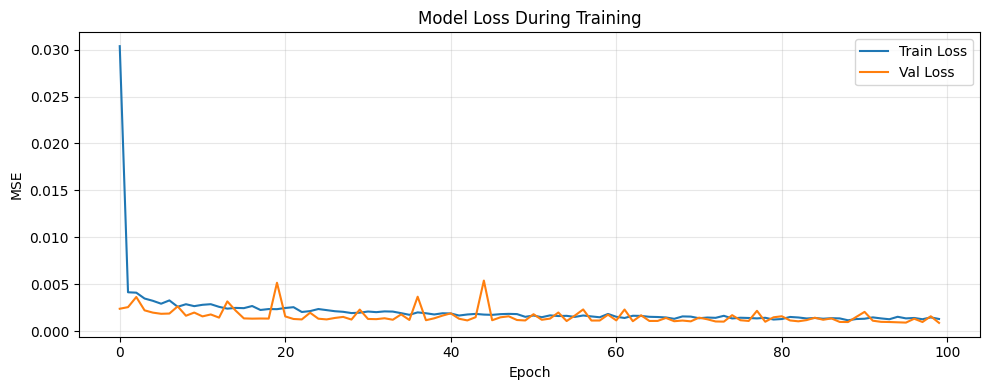

In [ ]:
# Plot training vs validation loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Evaluate on Test Set

In [ ]:
# Predict (output is still in [0,1] scale)
y_pred_scaled = model.predict(X_test)

# Inverse-transform back to USD
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'Test RMSE : ${rmse:.4f}')
print(f'Test MAE  : ${mae:.4f}')
print(f'Test MAPE : {mape:.2f}%')

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
Test RMSE : $7.4189
Test MAE  : $5.6343
Test MAPE : 2.68%


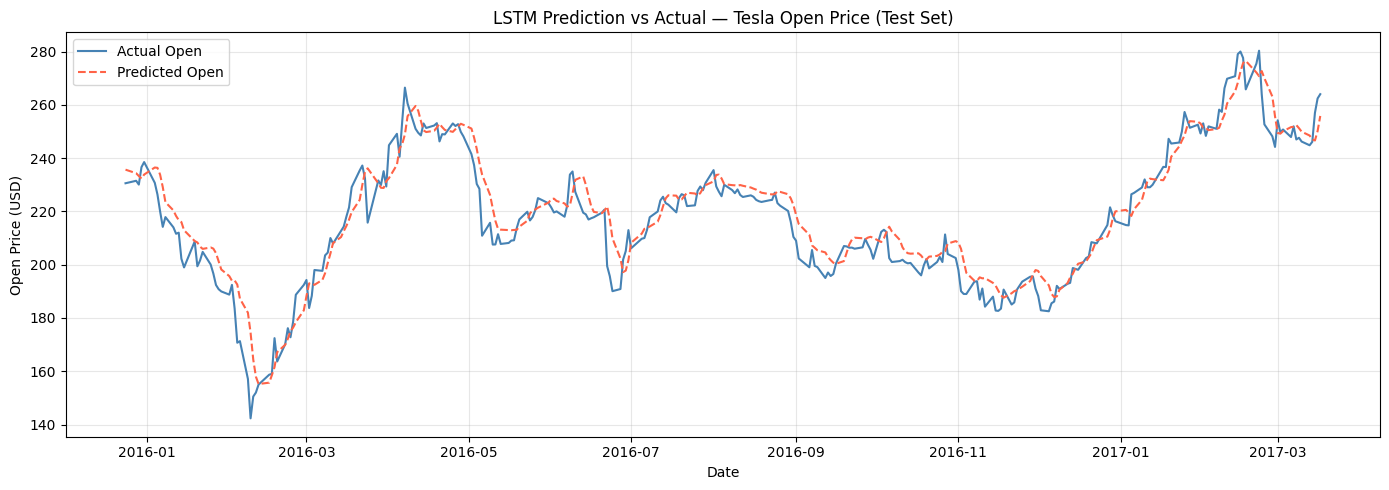

In [ ]:
# Plot predictions vs actual
test_dates = df['Date'].values[split_idx + WINDOW_SIZE:]

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_true,  label='Actual Open',    color='steelblue')
plt.plot(test_dates, y_pred,  label='Predicted Open', color='tomato', linestyle='--')
plt.title('LSTM Prediction vs Actual — Tesla Open Price (Test Set)')
plt.xlabel('Date')
plt.ylabel('Open Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Predict the Next Day (Inference Example)
Use the last 30 available days from the full dataset to predict the next trading day.

In [ ]:
last_30 = values[-WINDOW_SIZE:]                      # raw prices
last_30_scaled = scaler.transform(last_30)           # scale using fitted scaler
last_30_input  = last_30_scaled.reshape(1, WINDOW_SIZE, 1)  # batch of 1

next_day_scaled = model.predict(last_30_input)
next_day_price  = scaler.inverse_transform(next_day_scaled)[0, 0]

last_date = df['Date'].max()
print(f'Last date in dataset : {last_date.date()}')
print(f'Predicted Open price for next trading day: ${next_day_price:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Last date in dataset : 2017-03-17
Predicted Open price for next trading day: $260.8392
